# 7. Modelado Predictivo (Modular) — Screening Preanestésico

**Objetivo**: Predecir si un paciente requiere valoración preanestésica (`target=1`).
**Estrategia**: Maximizar Recall (Sensibilidad).

## 1. Setup y Carga de Módulos

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import warnings

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Agregar directorio raíz al path para importar utils
current_dir = os.getcwd()
if current_dir.endswith('notebook'):
    sys.path.append('..')
else:
    sys.path.append('.')

# Importar módulos personalizados
try:
    from utils.data_loader import load_opera_completo, load_features_metadata
    from utils.feature_engineering import resolve_feature_columns
    import utils.modeling as mod
    import utils.visualization as viz
    print("✅ Módulos 'utils' importados correctamente")
except ImportError as e:
    print(f"❌ Error importando módulos: {e}")
    print(f"PYTHONPATH: {sys.path}")

✅ Módulos 'utils' importados correctamente


## 2. Carga y Preparación de Datos

In [2]:
# 2.1 Cargar Dataset Maestro
try:
    df = load_opera_completo()
except FileNotFoundError as e:
    print(f"❌ {e}")
    raise

# 2.2 Cargar Metadatos de Features
try:
    features_meta = load_features_metadata()
    selected_names = features_meta['Variable'].tolist()
except FileNotFoundError as e:
    print(f"❌ {e}")
    raise

# 2.3 Resolver Columnas de Features
feature_columns, missing = resolve_feature_columns(selected_names, df.columns, features_meta)

print(f"\nResumen de Features:")
print(f"  - Seleccionadas (originales): {len(selected_names)}")
print(f"  - Resueltas en DataFrame:     {len(feature_columns)}")

if missing:
    print(f"⚠️ Features NO encontradas ({len(missing)}): {missing}")
else:
    print("✅ Todas las features fueron resueltas correctamente.")

Directorio actual: c:\Users\Usuario\Desktop\predictive-screening-preanesthesia\notebook
Cargando dataset completo (OPERA_COMPLETO.xlsx)...
✅ Dataset cargado desde: ../OPERA_COMPLETO.xlsx
   Dimensiones: 29,865 filas × 237 columnas
   Proporción target=1: 58.51%
✅ Metadatos de features cargados desde: ../features/variables_seleccionadas.csv

Resumen de Features:
  - Seleccionadas (originales): 61
  - Resueltas en DataFrame:     150
⚠️ Features NO encontradas (19): ['score_proc_high_severity → severity_score_high_severity_proc (not found)', 'score_proc_critical → severity_score_critical_proc (not found)', 'score_proc_moderate_severity → severity_score_moderate_severity_proc (not found)', 'score_proc_medium_severity → severity_score_medium_severity_proc (not found)', 'score_proc_low_severity → severity_score_low_severity_proc (not found)', 'score_dx_low_severity → severity_score_low_severity_dx (not found)', 'score_dx_high_severity → severity_score_high_severity_dx (not found)', 'score_dx

In [3]:
# 2.4 Construir X e y
X = df[feature_columns].copy()
y = df['target'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (29865, 150)
y shape: (29865,)


## 3. Split y Preprocesamiento (Standard)

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 3.1 Split Estratificado
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
pos_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio de desbalance (scale_pos_weight): {pos_weight_ratio:.4f}")

# 3.2 Imputación (Mediana para numérica, Moda para categórica si hubiera)
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# 3.3 Scaling (Solo para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

print("✅ Preprocesamiento completado.")

Train: 23,892 | Test: 5,973
Ratio de desbalance (scale_pos_weight): 0.7090
✅ Preprocesamiento completado.


## 4. Entrenamiento y Evaluación de Modelos

In [5]:
# 4.1 Definir Modelos Base
models_dict = mod.get_models_definitions(random_state=RANDOM_STATE, scale_pos_weight=pos_weight_ratio)

# 4.2 Entrenar y Evaluar
results = {}
predictions = {}

for name, model in models_dict.items():
    # Seleccionar datos adecuados (Scaled para LR, Imputed para Árboles)
    if name == 'Regresión Logística':
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train_imputed, X_test_imputed
        
    y_pred, y_proba, metrics = mod.evaluate_model_performance(
        name, model, X_tr, X_te, y_train, y_test
    )
    
    results[name] = metrics
    predictions[name] = {'y_pred': y_pred, 'y_proba': y_proba}

# 4.3 Tabla Comparativa
df_results = pd.DataFrame(results).T.sort_values('F2', ascending=False)
print(f"\n{'='*60}")
print("RÁNKING DE MODELOS (por F2-Score)")
print(f"{'='*60}")
print(df_results)


  Regresión Logística
  Recall      : 0.6200
  Precision   : 0.6755
  F1          : 0.6466
  F2          : 0.6304
  ROC-AUC     : 0.6504
  Brier       : 0.2311

  Árbol de Decisión
  Recall      : 0.8755
  Precision   : 0.6294
  F1          : 0.7323
  F2          : 0.8120
  ROC-AUC     : 0.6245
  Brier       : 0.2338

  Random Forest
  Recall      : 0.7110
  Precision   : 0.6671
  F1          : 0.6884
  F2          : 0.7018
  ROC-AUC     : 0.6567
  Brier       : 0.2276

  XGBoost
  Recall      : 0.6361
  Precision   : 0.6624
  F1          : 0.6490
  F2          : 0.6412
  ROC-AUC     : 0.6360
  Brier       : 0.2377

RÁNKING DE MODELOS (por F2-Score)
                       Recall  Precision        F1        F2   ROC-AUC  \
Árbol de Decisión    0.875536   0.629371  0.732320  0.812016  0.624496   
Random Forest        0.711016   0.667114  0.688366  0.701779  0.656705   
XGBoost              0.636052   0.662396  0.648956  0.641151  0.635992   
Regresión Logística  0.620029   0.675499  0.6

## 5. Visualización de Resultados

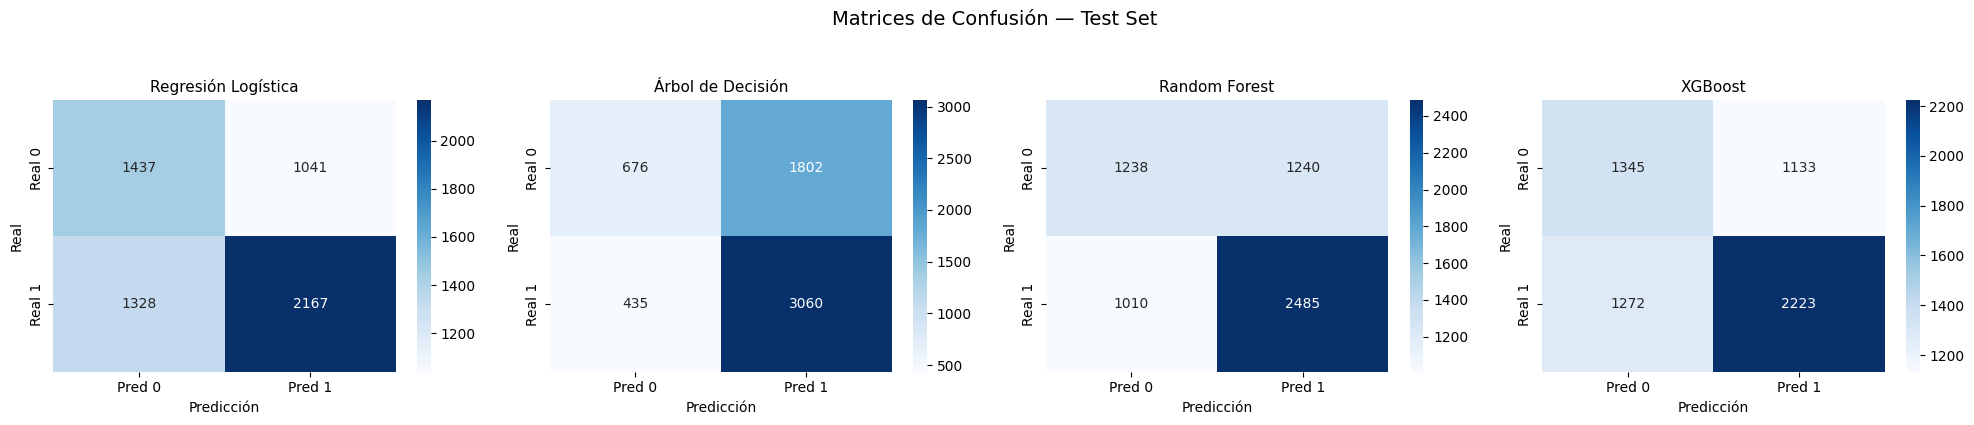

In [6]:
# 5.1 Matrices de Confusión
viz.plot_confusion_matrices(predictions, y_test, save_path='../matrices_confusion_modular.png')

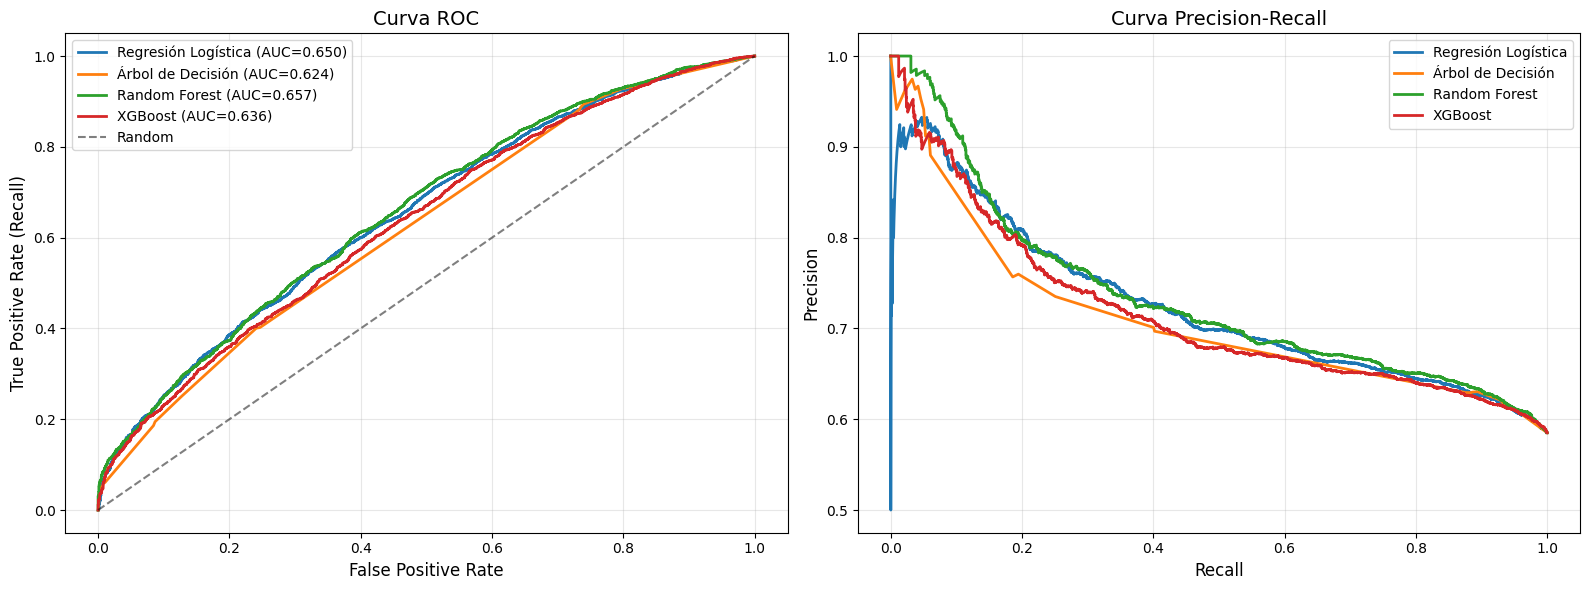

In [7]:
# 5.2 Curvas ROC y PR
viz.plot_roc_pr_curves(predictions, y_test, save_path='../curvas_roc_pr_modular.png')

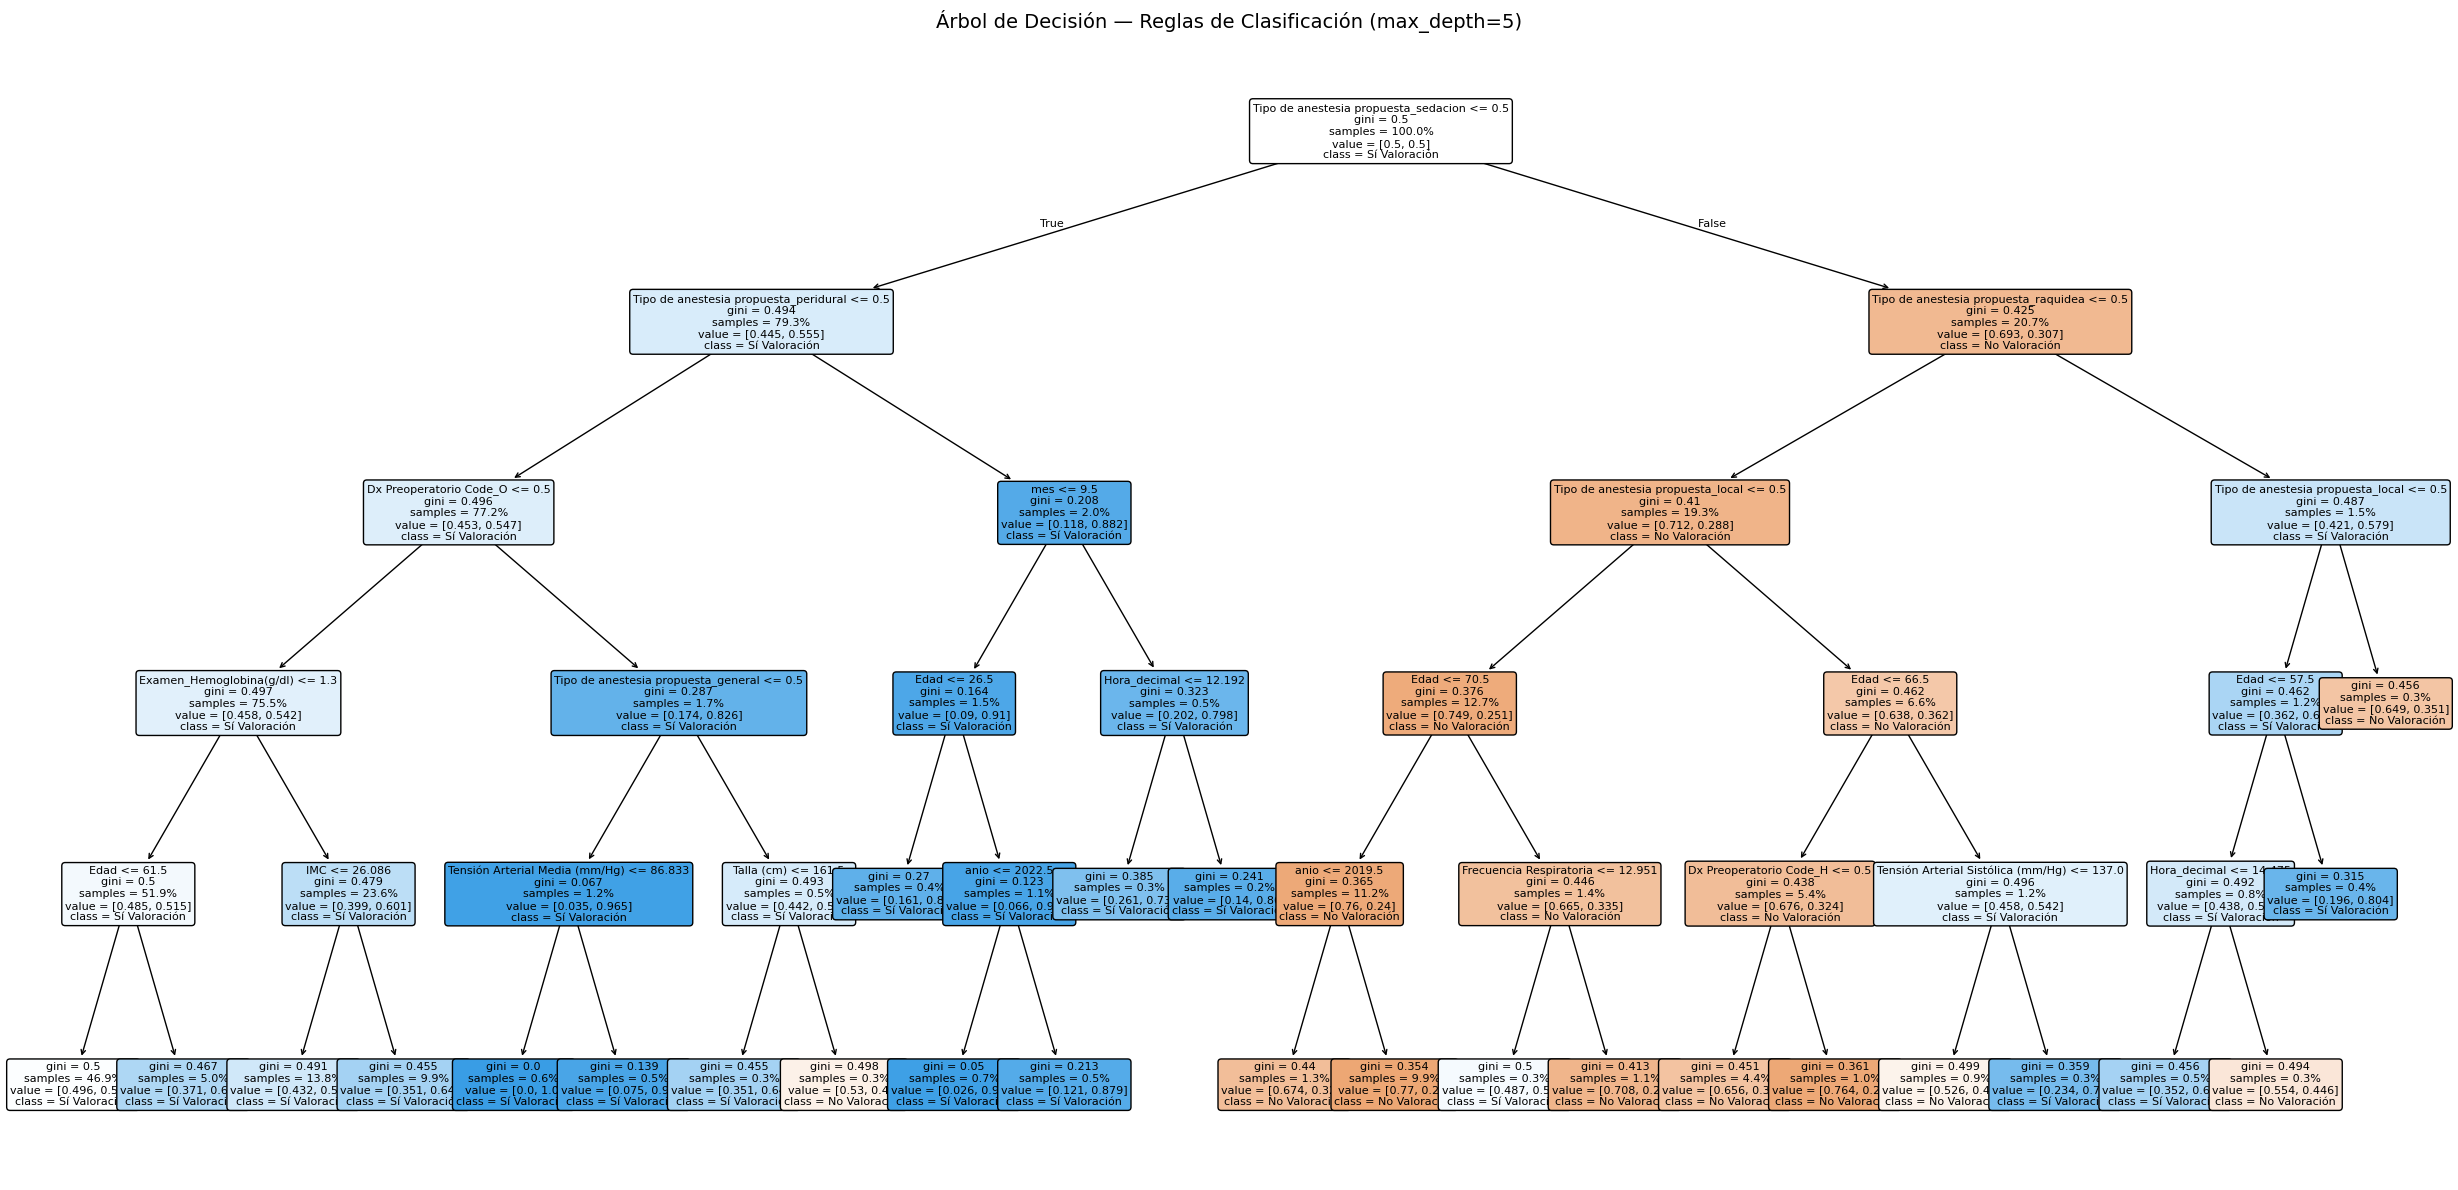

In [8]:
# 5.3 Reglas del Árbol de Decisión
viz.plot_decision_tree_rules(models_dict['Árbol de Decisión'], feature_columns, save_path='../arbol_decision_modular.png')

## 6. Optimización (Optuna) del Mejor Modelo

In [9]:
# 6.1 Identificar el Mejor Modelo (por F2-Score)
best_model_name = df_results.index[0]
best_f2_initial = df_results.iloc[0]['F2']

print(f"🏆 Mejor modelo pre-optimización: {best_model_name} (F2={best_f2_initial:.4f})")
print("Iniciando optimización de hiperparámetros...")

# Seleccionar datos (scaled o imputed según el modelo)
if best_model_name == 'Regresión Logística':
    X_train_opt = X_train_scaled
    X_test_opt = X_test_scaled
else:
    X_train_opt = X_train_imputed
    X_test_opt = X_test_imputed

# 6.2 Optimizar
study = mod.optimize_best_model(
    best_model_name, 
    X_train_opt, y_train, 
    random_state=RANDOM_STATE, 
    scale_pos_weight=pos_weight_ratio, # Solo usado por XGBoost, ignorado por otros
    n_trials=50
)

print(f"Mejor F2 (CV): {study.best_value:.4f}")
best_params = study.best_params
print(f"Mejores parámetros: {best_params}")

🏆 Mejor modelo pre-optimización: Árbol de Decisión (F2=0.8120)
Iniciando optimización de hiperparámetros...
Optimizing hyperparameters for: Árbol de Decisión
Mejor F2 (CV): 0.8215
Mejores parámetros: {'max_depth': 4, 'min_samples_split': 48, 'min_samples_leaf': 44, 'criterion': 'gini'}


In [10]:
# 6.3 Re-entrenar con mejores parámetros
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

final_model = None

if best_model_name == 'XGBoost':
    final_model = xgb.XGBClassifier(
        **best_params,
        scale_pos_weight=pos_weight_ratio,
        eval_metric='aucpr',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(
        **best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
elif best_model_name == 'Árbol de Decisión':
    final_model = DecisionTreeClassifier(
        **best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
elif best_model_name == 'Regresión Logística':
    final_model = LogisticRegression(
        **best_params,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    )

y_pred_opt, y_proba_opt, metrics_opt = mod.evaluate_model_performance(
    f'{best_model_name} Optimizado', final_model, 
    X_train_opt, X_test_opt, y_train, y_test
)

# Comparar mejora
print(f"\nMejora en F2: {metrics_opt['F2'] - best_f2_initial:.4f}")


  Árbol de Decisión Optimizado
  Recall      : 0.8893
  Precision   : 0.6316
  F1          : 0.7386
  F2          : 0.8222
  ROC-AUC     : 0.6235
  Brier       : 0.2335

Mejora en F2: 0.0102


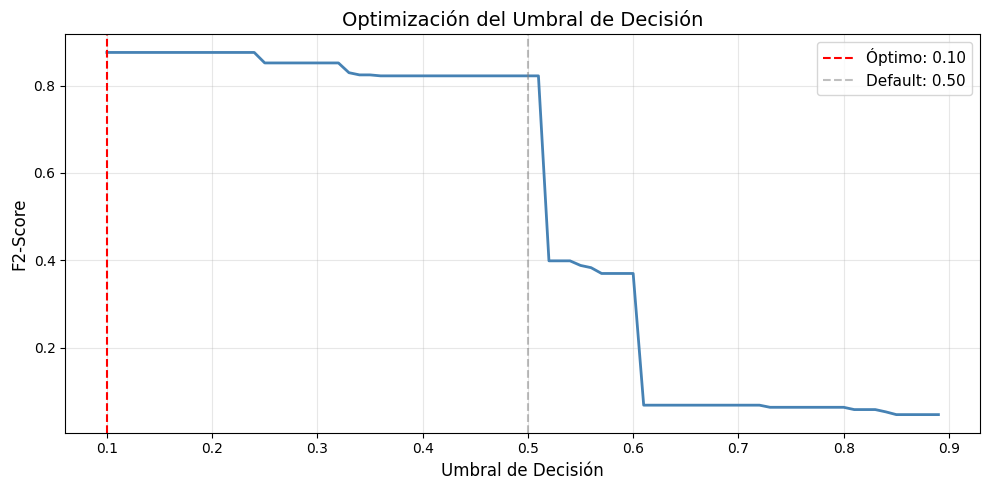

Umbral Óptimo: 0.10 (F2: 0.8758)


In [11]:
# 6.4 Optimización de Umbral
opt_thresh, opt_f2, thresholds, f2_scores = mod.find_optimal_threshold(y_test, y_proba_opt)

viz.plot_threshold_optimization(thresholds, f2_scores, opt_thresh, save_path='../umbral_optimo_modular.png')

print(f"Umbral Óptimo: {opt_thresh:.2f} (F2: {opt_f2:.4f})")

## 7. Interpretabilidad (SHAP)

Explicando modelo: DecisionTreeClassifier
SHAP shape original: (5973, 150, 2) -> Seleccionando clase 1
SHAP values shape final: (5973, 150)


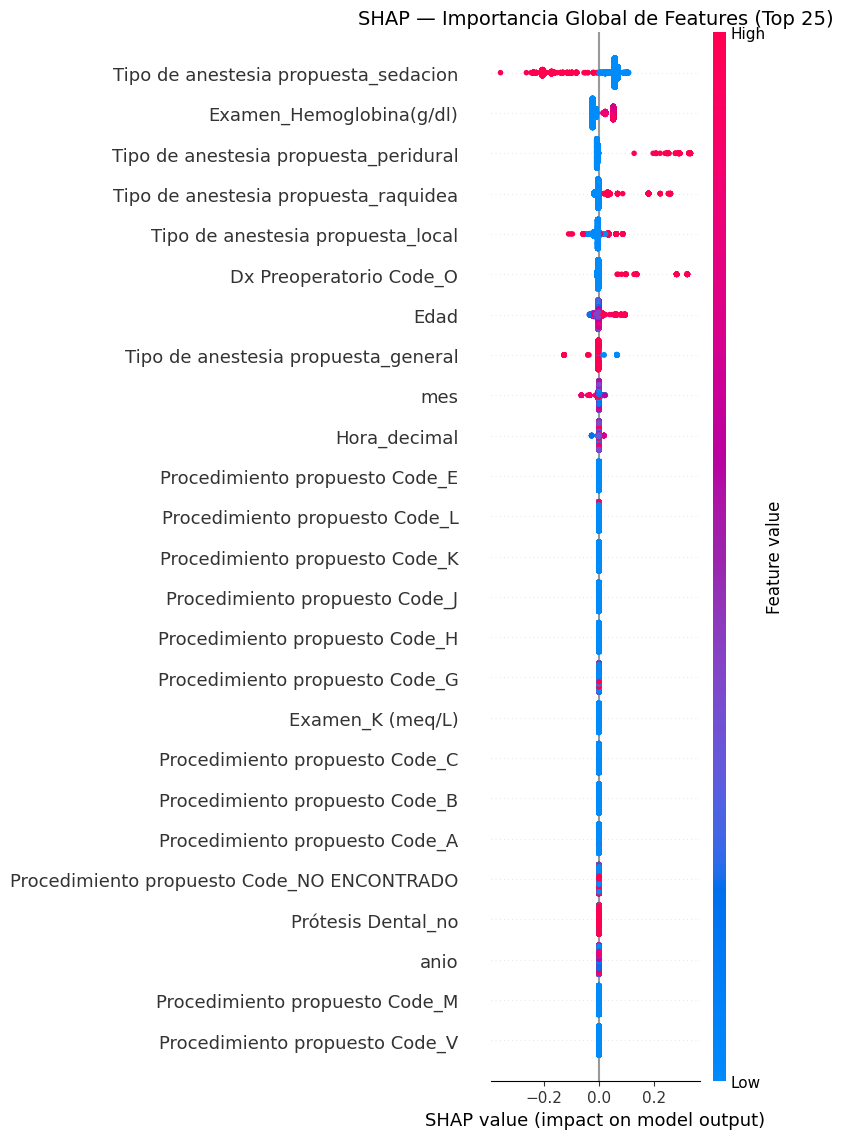

In [ ]:
import shap
import numpy as np

# Usar el modelo optimizado
print(f"Explicando modelo: {type(final_model).__name__}")

# Usar el wrapper genérico shap.Explainer que selecciona la mejor estrategia (Tree, Linear, etc.)
# Pasamos X_train_opt como background (necesario para Linear/Permutation)
if best_model_name in ['XGBoost', 'Random Forest', 'Árbol de Decisión']:
    # Para árboles, TreeExplainer es más rápido y exacto
    explainer = shap.TreeExplainer(final_model)
    # TreeExplainer retorna np.array o list de arrays en versiones viejas, 
    # pero Explanation object en llamadas nuevas si se usa explainer(X).
    # Usaremos la API explainer(X) que es más consistente.
    shap_explanation = explainer(X_test_opt)
    
elif best_model_name == 'Regresión Logística':
    # Para lineal, LinearExplainer con masker
    masker = shap.maskers.Independent(data=X_train_opt)
    explainer = shap.LinearExplainer(final_model, masker=masker)
    shap_explanation = explainer(X_test_opt)
    
else:
    # Fallback genérico (Permutation, etc.)
    explainer = shap.Explainer(final_model, X_train_opt)
    shap_explanation = explainer(X_test_opt)

# Procesar shap_explanation para obtener valores (N, F)
# shap_explanation.values puede ser (N, F) o (N, F, Classes)
vals = shap_explanation.values

if len(vals.shape) == 3:
    # Caso multiclase o binario proba: (N, Features, 2) -> Tomamos clase 1
    print(f"SHAP shape original: {vals.shape} -> Seleccionando clase 1")
    vals = vals[:, :, 1]
    
    # Ajustar base_value también si es necesario
    if hasattr(explainer, 'expected_value') and isinstance(explainer.expected_value, (list, np.ndarray)):
         pass 

# Asegurar que vals es (N, F)
print(f"SHAP values shape final: {vals.shape}")

# 7.1 Global Summary
viz.plot_shap_summary(vals, X_test_opt, save_path='../shap_summary_modular.png')

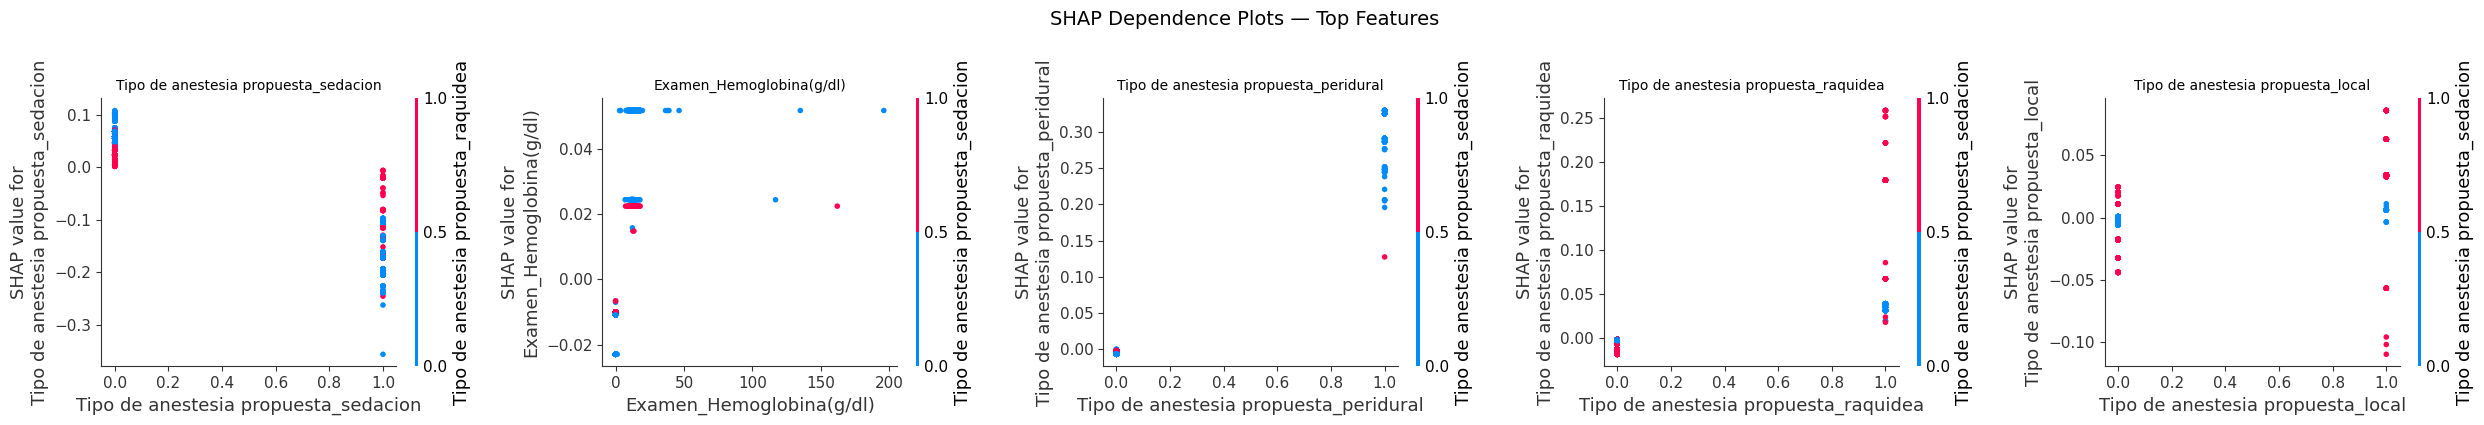

In [13]:
# 7.2 Top Features Dependence
# Calcular importancia media abs
shap_importance = np.abs(vals).mean(axis=0)
top_indices = np.argsort(shap_importance)[-5:][::-1]
top_features = [X_test_opt.columns[i] for i in top_indices]

viz.plot_shap_dependence(vals, X_test_opt, top_features, save_path='../shap_dependence_modular.png')

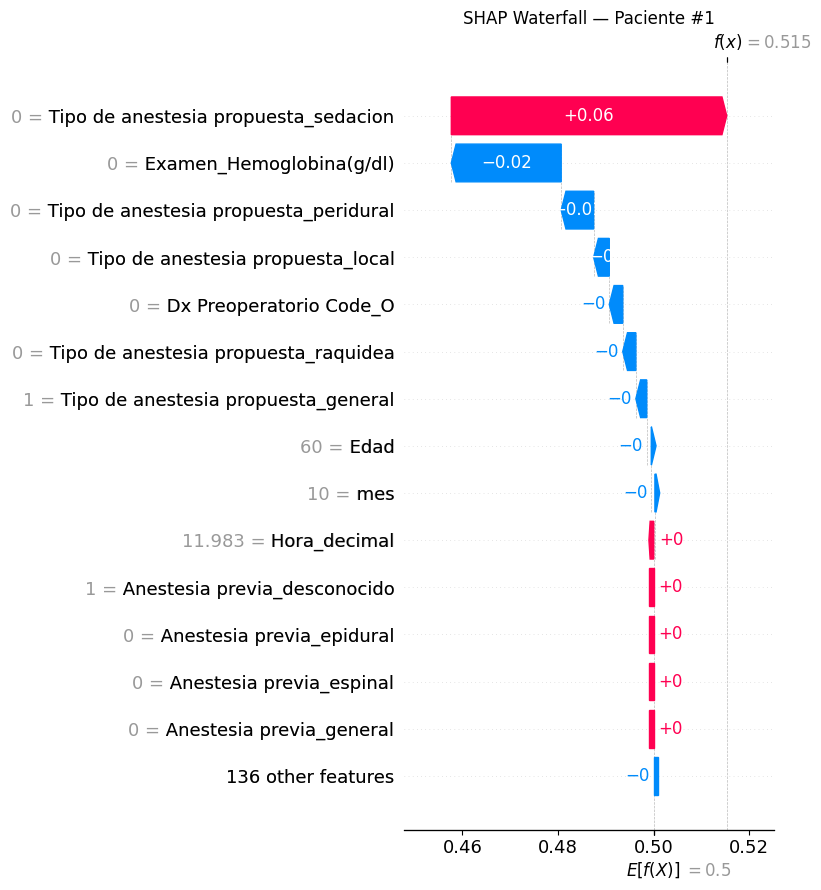

In [14]:
# 7.3 Ejemplo Local (Waterfall)
# Buscar un True Positive
tp_mask = (y_test.values == 1) & ((y_proba_opt >= opt_thresh).astype(int) == 1)
tp_indices = np.where(tp_mask)[0]

if len(tp_indices) > 0:
    idx = tp_indices[0]
    
    # Preparar objeto Explanation para waterfall
    # Necesitamos reconstruir un objeto Explanation simple para la visualización
    
    # Obtener expected_value correcto
    if hasattr(explainer, 'expected_value'):
        ev = explainer.expected_value
        if isinstance(ev, (list, np.ndarray)) and len(ev) > 1:
            ev = ev[1]
    else:
        # Fallback si no tiene expected_value directo (API nueva calculation)
        ev = shap_explanation.base_values[idx]
        if isinstance(ev, (list, np.ndarray)) and len(ev) > 1: # Si es array por clase
             ev = ev[1]
    
    viz.plot_shap_waterfall(vals, explainer, X_test_opt, idx, save_path='../shap_waterfall_modular.png')